# Phase 1: Detection & Localization

This notebook focuses on the initial detection phase:
1. Hand Detection
2. Bird Segmentation
3. Chest Localization

In [1]:
import sys
sys.path.append('..')

import cv2
import numpy as np
import matplotlib.pyplot as plt
import yaml

from src.detectors import get_detector
from src.segmenters import get_segmenter, convert_mask_to_frame_coords
from src.localizers import get_localizer

%matplotlib inline
plt.rcParams['figure.figsize'] = (15, 10)

## Load Configuration

In [2]:
with open('../configs/default.yaml', 'r') as f:
    config = yaml.safe_load(f)

print("Configuration loaded")

Configuration loaded


## Step 1: Hand Detection

Loading YOLO model: yolov8n-seg.pt on cuda
✓ YOLODetector initialized (device: cuda)


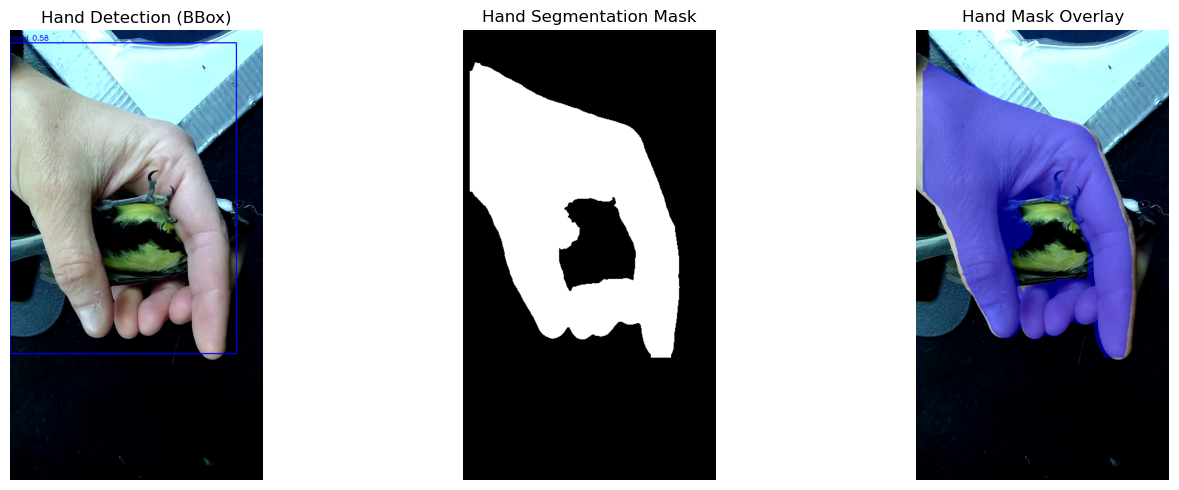

Hand detected: True
Confidence: 0.58
Hand mask pixels: 650014


In [3]:
# Initialize detector
detector = get_detector(config['detection'])

video_name = "H5_M_1"

# Load test frame
cap = cv2.VideoCapture(f'../data/videos/{video_name}.mp4')
ret, frame = cap.read()
cap.release()

if not ret:
    print("Error: Could not read video")
else:
    # Detect hand (now returns hand_mask as well)
    hand_bbox, confidence, hand_mask = detector.detect(frame)
    
    # Visualize
    fig, axes = plt.subplots(1, 2 if hand_mask is None else 3, figsize=(15, 5))
    
    # Original frame with hand bbox
    vis = frame.copy()
    if hand_bbox:
        x, y, w, h = [int(v) for v in hand_bbox]
        cv2.rectangle(vis, (x, y), (x+w, y+h), (255, 0, 0), 3)
        cv2.putText(vis, f"Hand {confidence:.2f}", (x, y-10),
                   cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)
    
    axes[0].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Hand Detection (BBox)')
    axes[0].axis('off')
    
    # Hand mask visualization
    if hand_mask is not None:
        axes[1].imshow(hand_mask, cmap='gray')
        axes[1].set_title('Hand Segmentation Mask')
        axes[1].axis('off')
        
        # Overlay mask on frame
        overlay = frame.copy()
        overlay[hand_mask > 0] = overlay[hand_mask > 0] * 0.5 + np.array([255, 0, 0]) * 0.5
        axes[2].imshow(cv2.cvtColor(overlay.astype(np.uint8), cv2.COLOR_BGR2RGB))
        axes[2].set_title('Hand Mask Overlay')
        axes[2].axis('off')
    else:
        axes[1].text(0.5, 0.5, 'No hand mask\n(use yolov8n-seg.pt)', 
                    ha='center', va='center', fontsize=14)
        axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Hand detected: {hand_bbox is not None}")
    if hand_bbox:
        print(f"Confidence: {confidence:.2f}")
    if hand_mask is not None:
        print(f"Hand mask pixels: {np.sum(hand_mask > 0)}")

## Step 2: Bird Segmentation

✓ GrabCutSegmenter initialized (iterations=8, rect_margin=0.15)


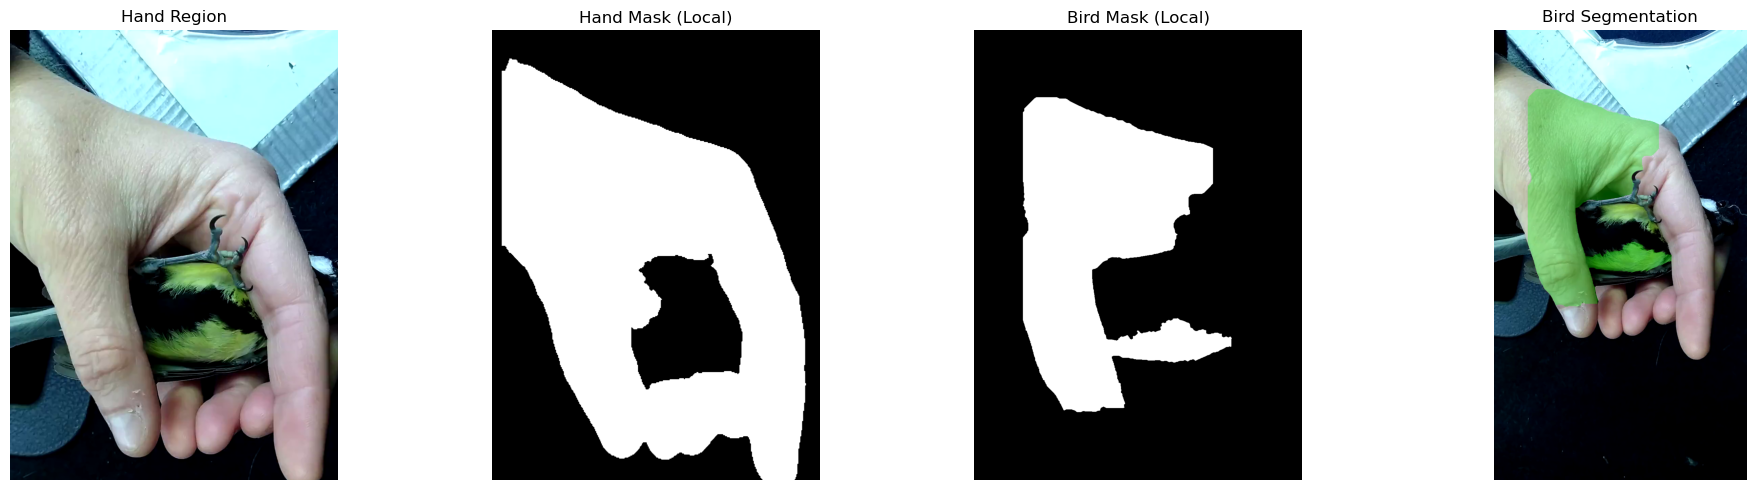

Bird pixels: 331456
Hand mask used for improved segmentation: 648439 pixels


In [4]:
if hand_bbox:
    # Initialize segmenter
    segmenter = get_segmenter(config['segmentation'])
    
    # Extract hand region
    x, y, w, h = [int(v) for v in hand_bbox]
    hand_region = frame[y:y+h, x:x+w]
    
    # Extract hand mask in local coordinates if available
    hand_mask_local = None
    if hand_mask is not None:
        hand_mask_local = hand_mask[y:y+h, x:x+w]
    
    # Segment bird (with optional hand mask)
    bird_mask_local = segmenter.segment(hand_region, hand_mask_local=hand_mask_local)
    bird_mask_local = segmenter.get_largest_component(bird_mask_local)
    
    # Convert to frame coordinates
    bird_mask = convert_mask_to_frame_coords(bird_mask_local, hand_bbox, frame.shape)
    
    # Visualize
    num_cols = 4 if hand_mask_local is not None else 3
    fig, axes = plt.subplots(1, num_cols, figsize=(5*num_cols, 5))
    
    axes[0].imshow(cv2.cvtColor(hand_region, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Hand Region')
    axes[0].axis('off')
    
    if hand_mask_local is not None:
        axes[1].imshow(hand_mask_local, cmap='gray')
        axes[1].set_title('Hand Mask (Local)')
        axes[1].axis('off')
        
        axes[2].imshow(bird_mask_local, cmap='gray')
        axes[2].set_title('Bird Mask (Local)')
        axes[2].axis('off')
        
        # Overlay on original
        overlay = frame.copy()
        overlay[bird_mask > 0] = [0, 255, 0]
        vis = cv2.addWeighted(frame, 0.7, overlay, 0.3, 0)
        
        axes[3].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        axes[3].set_title('Bird Segmentation')
        axes[3].axis('off')
    else:
        axes[1].imshow(bird_mask_local, cmap='gray')
        axes[1].set_title('Bird Mask (Local)')
        axes[1].axis('off')
        
        # Overlay on original
        overlay = frame.copy()
        overlay[bird_mask > 0] = [0, 255, 0]
        vis = cv2.addWeighted(frame, 0.7, overlay, 0.3, 0)
        
        axes[2].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        axes[2].set_title('Bird Segmentation')
        axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Bird pixels: {np.sum(bird_mask > 0)}")
    if hand_mask_local is not None:
        print(f"Hand mask used for improved segmentation: {np.sum(hand_mask_local > 0)} pixels")

## Step 3: Chest Localization

✓ OpticalFlowLocalizer initialized (buffer=30, grid=8x8, roi=6x6 cells, freq_range=[0.5, 4.0] Hz)


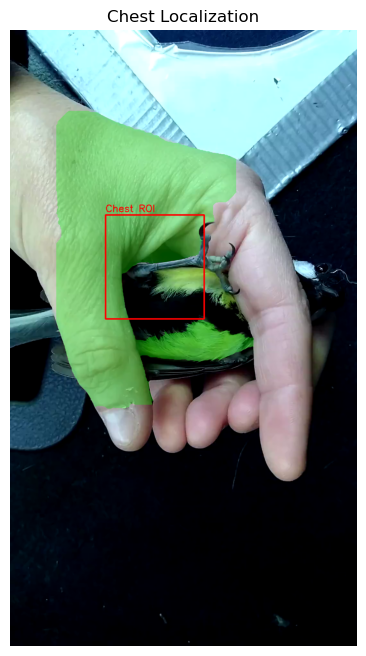

Chest ROI: (297, 576, 307, 324)
Chest size: 307x324 pixels


In [5]:
if hand_bbox and np.sum(bird_mask) > 0:
    # Initialize localizer
    localizer = get_localizer(config['localization'])
    
    # Locate chest
    chest_roi = localizer.locate(bird_mask)
    
    if chest_roi:
        # Visualize
        vis = frame.copy()
        
        # Draw bird mask
        overlay = vis.copy()
        overlay[bird_mask > 0] = [0, 255, 0]
        vis = cv2.addWeighted(vis, 0.7, overlay, 0.3, 0)
        
        # Draw chest ROI
        cx, cy, cw, ch = [int(v) for v in chest_roi]
        cv2.rectangle(vis, (cx, cy), (cx+cw, cy+ch), (0, 0, 255), 3)
        cv2.putText(vis, "Chest ROI", (cx, cy-10),
                   cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
        
        plt.figure(figsize=(12, 8))
        plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        plt.title('Chest Localization')
        plt.axis('off')
        plt.show()
        
        print(f"Chest ROI: {chest_roi}")
        print(f"Chest size: {cw}x{ch} pixels")

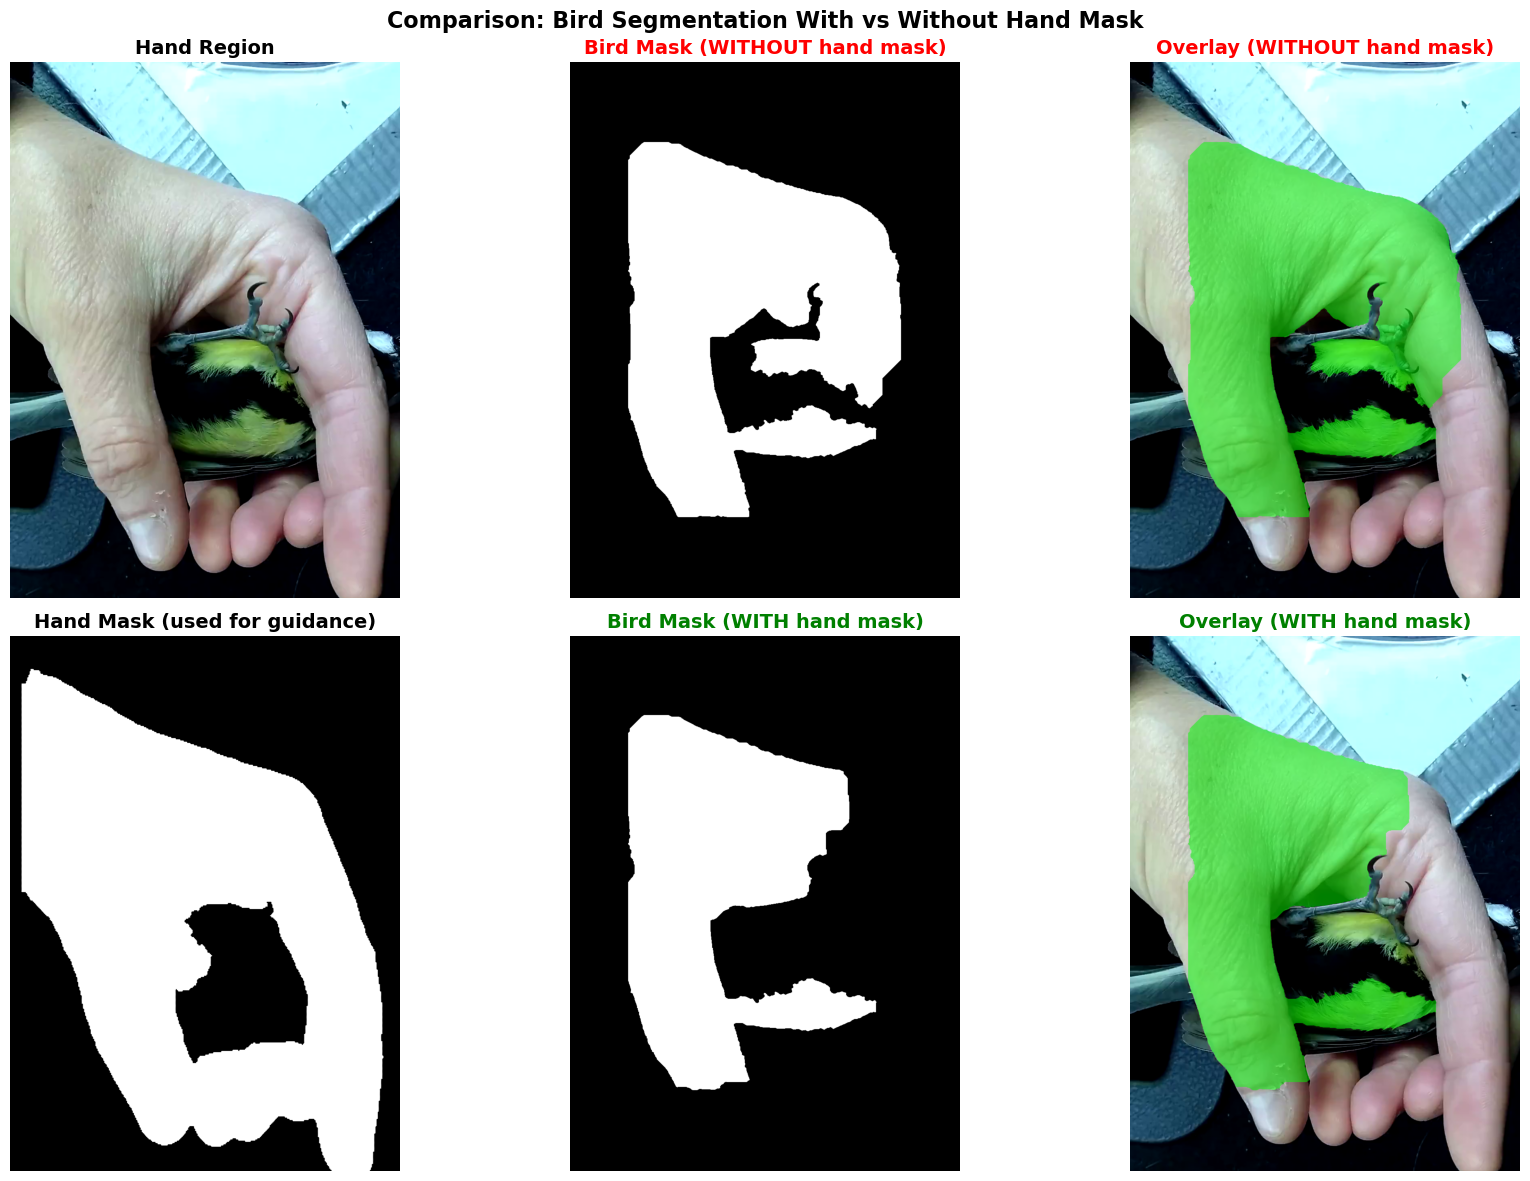

COMPARISON RESULTS
Bird pixels WITHOUT hand mask: 413474
Bird pixels WITH hand mask:    330133
Difference:                    83341 pixels (20.2%)

✓ Hand mask helped REDUCE false positives (likely hand pixels)


In [6]:
if hand_bbox and hand_mask is not None:
    # Segment WITHOUT hand mask (old method)
    bird_mask_no_hand = segmenter.segment(hand_region, hand_mask_local=None)
    bird_mask_no_hand = segmenter.get_largest_component(bird_mask_no_hand)
    
    # Segment WITH hand mask (new method)
    bird_mask_with_hand = segmenter.segment(hand_region, hand_mask_local=hand_mask_local)
    bird_mask_with_hand = segmenter.get_largest_component(bird_mask_with_hand)
    
    # Visualize comparison
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # Row 1: Without hand mask
    axes[0, 0].imshow(cv2.cvtColor(hand_region, cv2.COLOR_BGR2RGB))
    axes[0, 0].set_title('Hand Region', fontsize=14, fontweight='bold')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(bird_mask_no_hand, cmap='gray')
    axes[0, 1].set_title('Bird Mask (WITHOUT hand mask)', fontsize=14, fontweight='bold', color='red')
    axes[0, 1].axis('off')
    
    # Overlay without hand mask
    overlay_no_hand = hand_region.copy()
    overlay_no_hand[bird_mask_no_hand > 0] = overlay_no_hand[bird_mask_no_hand > 0] * 0.5 + np.array([0, 255, 0]) * 0.5
    axes[0, 2].imshow(cv2.cvtColor(overlay_no_hand.astype(np.uint8), cv2.COLOR_BGR2RGB))
    axes[0, 2].set_title('Overlay (WITHOUT hand mask)', fontsize=14, fontweight='bold', color='red')
    axes[0, 2].axis('off')
    
    # Row 2: With hand mask
    axes[1, 0].imshow(hand_mask_local, cmap='gray')
    axes[1, 0].set_title('Hand Mask (used for guidance)', fontsize=14, fontweight='bold')
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(bird_mask_with_hand, cmap='gray')
    axes[1, 1].set_title('Bird Mask (WITH hand mask)', fontsize=14, fontweight='bold', color='green')
    axes[1, 1].axis('off')
    
    # Overlay with hand mask
    overlay_with_hand = hand_region.copy()
    overlay_with_hand[bird_mask_with_hand > 0] = overlay_with_hand[bird_mask_with_hand > 0] * 0.5 + np.array([0, 255, 0]) * 0.5
    axes[1, 2].imshow(cv2.cvtColor(overlay_with_hand.astype(np.uint8), cv2.COLOR_BGR2RGB))
    axes[1, 2].set_title('Overlay (WITH hand mask)', fontsize=14, fontweight='bold', color='green')
    axes[1, 2].axis('off')
    
    plt.suptitle('Comparison: Bird Segmentation With vs Without Hand Mask', fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()
    
    # Calculate differences
    pixels_without = np.sum(bird_mask_no_hand > 0)
    pixels_with = np.sum(bird_mask_with_hand > 0)
    difference = pixels_without - pixels_with
    
    print("=" * 60)
    print("COMPARISON RESULTS")
    print("=" * 60)
    print(f"Bird pixels WITHOUT hand mask: {pixels_without}")
    print(f"Bird pixels WITH hand mask:    {pixels_with}")
    print(f"Difference:                    {difference} pixels ({difference/pixels_without*100:.1f}%)")
    print()
    
    if difference > 0:
        print("✓ Hand mask helped REDUCE false positives (likely hand pixels)")
    elif difference < 0:
        print("⚠ Hand mask resulted in MORE pixels (check if hand mask is accurate)")
    else:
        print("• No difference in pixel count")
    
    print("=" * 60)
else:
    print("Hand mask not available. Use a YOLO segmentation model (e.g., yolov8n-seg.pt) to see the comparison.")

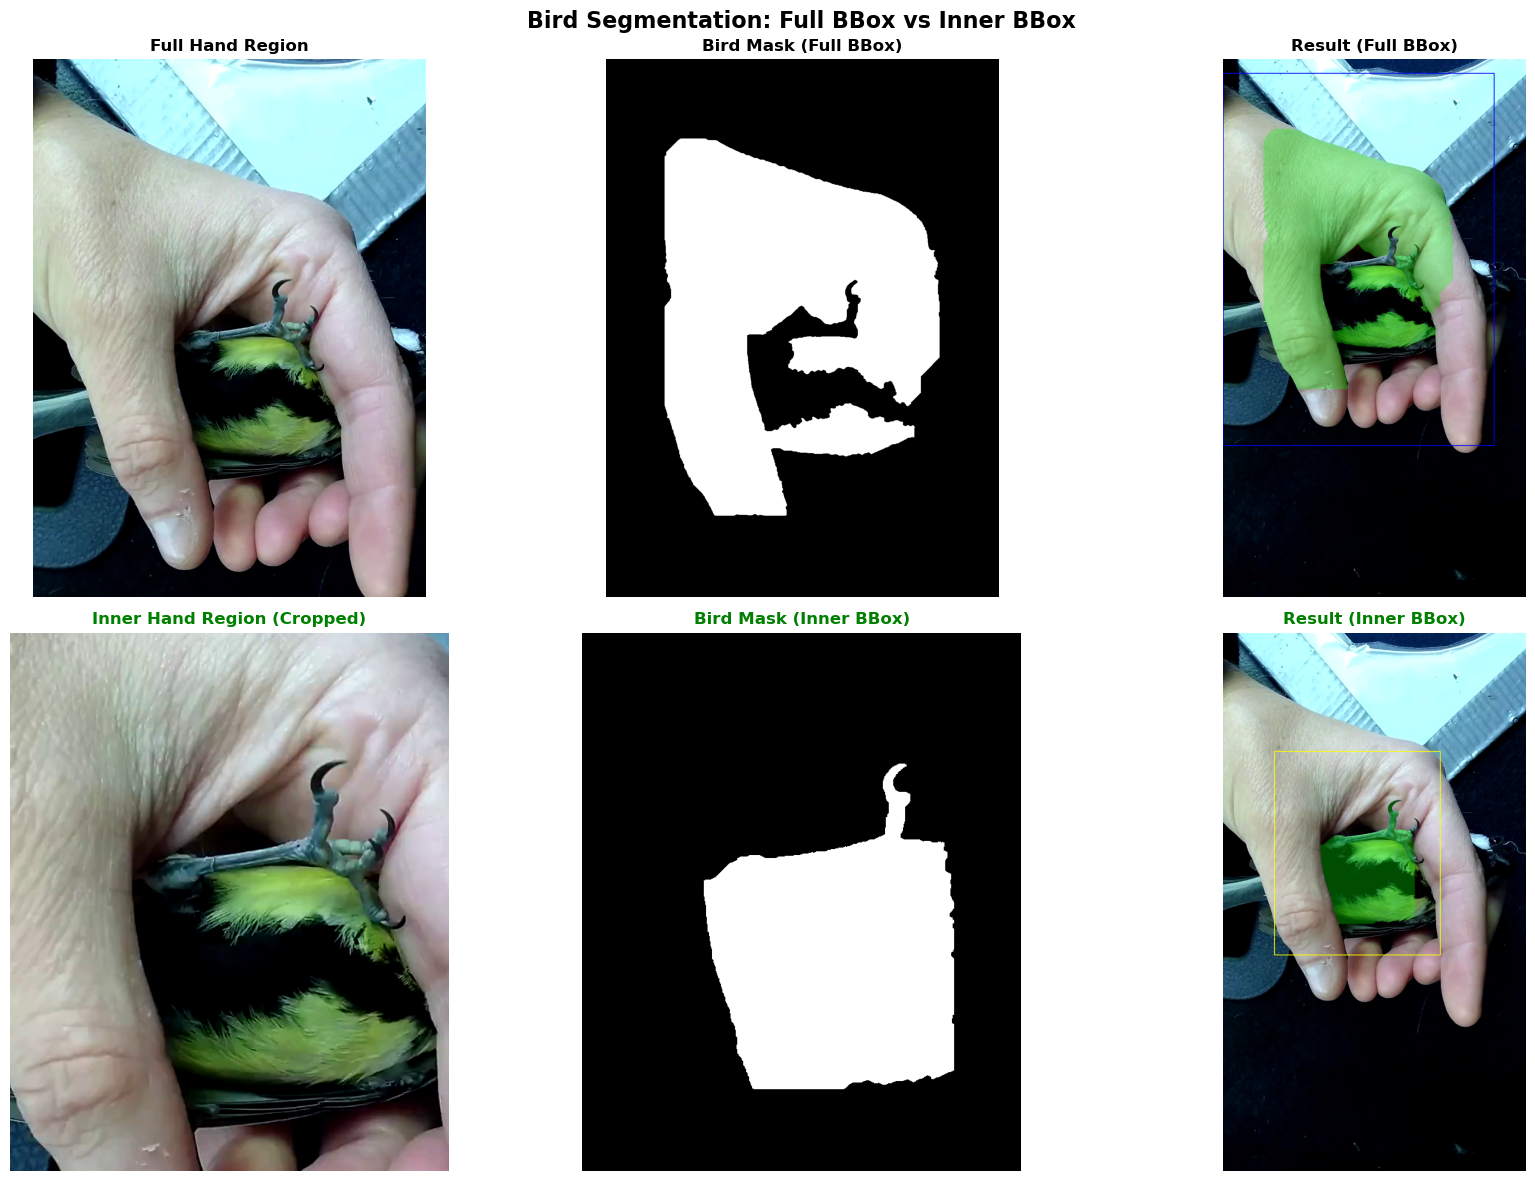

SEGMENTATION COMPARISON
Full hand bbox approach:
  Region size: 966x1326 = 1280916 pixels
  Bird pixels: 414517

Inner hand bbox approach:
  Region size: 591x725 = 428475 pixels
  Bird pixels: 100600
  Processing speedup: 3.0x faster

OBSERVATIONS:
  ✓ Inner bbox excludes finger edges from analysis
  ✓ Smaller region = faster GrabCut computation
  ✓ Cleaner bird mask (less hand contamination)


In [7]:
from src.utils import get_inner_hand_bbox

if hand_bbox and hand_mask is not None:
    # Get inner bbox
    inner_bbox = get_inner_hand_bbox(hand_mask, hand_bbox, method='percentile', margin_ratio=0.15)
    
    # Segment bird with FULL hand bbox (original approach)
    x_full, y_full, w_full, h_full = [int(v) for v in hand_bbox]
    region_full = frame[y_full:y_full+h_full, x_full:x_full+w_full]
    mask_local_full = hand_mask[y_full:y_full+h_full, x_full:x_full+w_full]
    
    bird_mask_full = segmenter.segment(region_full, hand_mask_local=mask_local_full)
    bird_mask_full = segmenter.get_largest_component(bird_mask_full)
    bird_mask_full_frame = convert_mask_to_frame_coords(bird_mask_full, hand_bbox, frame.shape)
    
    # Segment bird with INNER hand bbox (new approach)
    x_inner, y_inner, w_inner, h_inner = [int(v) for v in inner_bbox]
    region_inner = frame[y_inner:y_inner+h_inner, x_inner:x_inner+w_inner]
    mask_local_inner = hand_mask[y_inner:y_inner+h_inner, x_inner:x_inner+w_inner]
    
    bird_mask_inner = segmenter.segment(region_inner, hand_mask_local=mask_local_inner)
    bird_mask_inner = segmenter.get_largest_component(bird_mask_inner)
    bird_mask_inner_frame = convert_mask_to_frame_coords(bird_mask_inner, inner_bbox, frame.shape)
    
    # Visualize comparison
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # Row 1: Full hand bbox
    axes[0, 0].imshow(cv2.cvtColor(region_full, cv2.COLOR_BGR2RGB))
    axes[0, 0].set_title('Full Hand Region', fontsize=12, fontweight='bold')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(bird_mask_full, cmap='gray')
    axes[0, 1].set_title('Bird Mask (Full BBox)', fontsize=12, fontweight='bold')
    axes[0, 1].axis('off')
    
    vis_full = frame.copy()
    overlay = vis_full.copy()
    overlay[bird_mask_full_frame > 0] = [0, 255, 0]
    vis_full = cv2.addWeighted(vis_full, 0.7, overlay, 0.3, 0)
    hx, hy, hw, hh = [int(v) for v in hand_bbox]
    cv2.rectangle(vis_full, (hx, hy), (hx+hw, hy+hh), (255, 0, 0), 2)
    axes[0, 2].imshow(cv2.cvtColor(vis_full, cv2.COLOR_BGR2RGB))
    axes[0, 2].set_title('Result (Full BBox)', fontsize=12, fontweight='bold')
    axes[0, 2].axis('off')
    
    # Row 2: Inner hand bbox
    axes[1, 0].imshow(cv2.cvtColor(region_inner, cv2.COLOR_BGR2RGB))
    axes[1, 0].set_title('Inner Hand Region (Cropped)', fontsize=12, fontweight='bold', color='green')
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(bird_mask_inner, cmap='gray')
    axes[1, 1].set_title('Bird Mask (Inner BBox)', fontsize=12, fontweight='bold', color='green')
    axes[1, 1].axis('off')
    
    vis_inner = frame.copy()
    overlay = vis_inner.copy()
    overlay[bird_mask_inner_frame > 0] = [0, 255, 0]
    vis_inner = cv2.addWeighted(vis_inner, 0.7, overlay, 0.3, 0)
    ix, iy, iw, ih = [int(v) for v in inner_bbox]
    cv2.rectangle(vis_inner, (ix, iy), (ix+iw, iy+ih), (0, 255, 255), 2)
    axes[1, 2].imshow(cv2.cvtColor(vis_inner, cv2.COLOR_BGR2RGB))
    axes[1, 2].set_title('Result (Inner BBox)', fontsize=12, fontweight='bold', color='green')
    axes[1, 2].axis('off')
    
    plt.suptitle('Bird Segmentation: Full BBox vs Inner BBox', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Compare results
    pixels_full = np.sum(bird_mask_full_frame > 0)
    pixels_inner = np.sum(bird_mask_inner_frame > 0)
    
    # Count hand pixels in bird mask (pixels outside inner bbox but inside bird mask)
    hand_pixels_in_full = np.sum((bird_mask_full_frame > 0) & (hand_mask > 0) & 
                                   ((np.arange(frame.shape[0])[:, None] < iy) | 
                                    (np.arange(frame.shape[0])[:, None] >= iy+ih) |
                                    (np.arange(frame.shape[1])[None, :] < ix) |
                                    (np.arange(frame.shape[1])[None, :] >= ix+iw)))
    
    print("=" * 70)
    print("SEGMENTATION COMPARISON")
    print("=" * 70)
    print(f"Full hand bbox approach:")
    print(f"  Region size: {w_full}x{h_full} = {w_full*h_full} pixels")
    print(f"  Bird pixels: {pixels_full}")
    print()
    print(f"Inner hand bbox approach:")
    print(f"  Region size: {w_inner}x{h_inner} = {w_inner*h_inner} pixels")
    print(f"  Bird pixels: {pixels_inner}")
    print(f"  Processing speedup: {(w_full*h_full)/(w_inner*h_inner):.1f}x faster")
    print()
    print("OBSERVATIONS:")
    print("  ✓ Inner bbox excludes finger edges from analysis")
    print("  ✓ Smaller region = faster GrabCut computation")
    print("  ✓ Cleaner bird mask (less hand contamination)")
    print("=" * 70)
else:
    print("Need hand mask for comparison.")